# ME 3300 Lab 05 — Solution Notebook
**Operational Amplifiers: Non-Inverting and Instrumentation Amplifier Circuits**

Instructor solution. Acquisition cells (dwfpy) are guarded by
`ADS_CONNECTED = False` so the notebook runs end-to-end against the synthetic
TA dataset in `../Data/` (from `generate_synthetic_data.py`). Set the flag
True at the bench to exercise the hardware path.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from datetime import date

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'Times', 'DejaVu Serif']
plt.rcParams['font.size'] = 10

ADS_CONNECTED = False  # True only at the bench with hardware attached
today = date.today().strftime('%b %d, %Y')

## Expected gains from measured components (manual Part-1 / Part-4)

In [2]:
# Measured with the DMM — students substitute THEIR values
R1  = 9960.0     # ohms (nominal 10 k)
R2  = 19890.0    # ohms (nominal 20 k)
R_G = 24870.0    # ohms (nominal 24.9 k)

G_expected_lm = 1 + R2 / R1            # non-inverting amp, Eq. 2
G_expected_ad = 1 + 50500.0 / R_G      # AD622, Eq. 3 (50.5 kΩ from datasheet)

print(f"LM358 expected gain: {G_expected_lm:.4f}")
print(f"AD622 expected gain: {G_expected_ad:.4f}")

LM358 expected gain: 2.9970
AD622 expected gain: 3.0306


## Part-3 — scripted DC sweep (hardware path)

The same script serves both amplifiers; only the output filename changes.
Runs only with hardware; otherwise the synthetic sweeps in `../Data/` are
used.

In [3]:
if ADS_CONNECTED:
    import dwfpy as dwf
    import time

    set_points = np.linspace(-5.0, 5.0, 41)    # W1 setpoints (V)
    v_in_meas  = []
    v_out_meas = []

    fs, duration = 1000, 0.5
    n = int(fs * duration)

    with dwf.Device() as device:
        supplies = device.analog_io                 # the Supplies instrument
        supplies['V+']['Voltage'].value = 12.0
        supplies['V+']['Enable'].value  = True
        supplies['V-']['Voltage'].value = -12.0
        supplies['V-']['Enable'].value  = True
        supplies.master_enable = True
        time.sleep(0.5)                             # let the rails come up

        wavegen = device.analog_output
        scope   = device.analog_input
        scope['ch1'].setup(range=5.0)               # amplifier input
        scope['ch2'].setup(range=25.0)              # output can reach ±11 V!

        for v_set in set_points:
            wavegen['ch1'].setup('dc', offset=v_set, start=True)
            time.sleep(0.1)                         # settle

            scope.single(sample_rate=fs, buffer_size=n, configure=True, start=True)
            v_in_meas.append(scope['ch1'].get_data().mean())
            v_out_meas.append(scope['ch2'].get_data().mean())
            print(f"W1 {v_set:+.2f} V -> in {v_in_meas[-1]:+.4f} V, "
                  f"out {v_out_meas[-1]:+.4f} V")

        supplies.master_enable = False              # rails off before rewiring

    np.savetxt('../Data/LM358_Sweep.csv',           # AD622_Sweep.csv on run 2
               np.column_stack([set_points, v_in_meas, v_out_meas]),
               header='set_V,vin_V,vout_V', delimiter=',')

## Part-5 — fit the linear region of each sweep

The boolean mask keeps points safely away from the rails; the slope of the
fit IS the measured gain. Fit statistics follow Lab 02 (s_yx, 95% CI on the
slope).

In [4]:
def fit_gain(fname):
    """Load a sweep CSV, fit its linear region, return everything needed."""
    data = np.loadtxt(fname, delimiter=',', comments='#')
    v_in, v_out = data[:, 1], data[:, 2]

    linear = np.abs(v_out) < 9.5           # True where NOT saturated
    coeffs = np.polyfit(v_in[linear], v_out[linear], 1)
    G_fit, offset = coeffs

    N      = np.count_nonzero(linear)      # points in the linear region
    nu     = N - 2
    resid  = v_out[linear] - np.polyval(coeffs, v_in[linear])
    norm_r = np.sqrt(np.sum(resid**2))
    s_yx   = norm_r / np.sqrt(nu)
    S_G    = s_yx / np.sqrt(np.sum((v_in[linear] - v_in[linear].mean())**2))
    CI_G   = stats.t.ppf(0.975, df=nu) * S_G

    return v_in, v_out, linear, coeffs, G_fit, CI_G, s_yx


v_in_lm, v_out_lm, lin_lm, c_lm, G_lm, CI_lm, syx_lm = fit_gain('../Data/LM358_Sweep.csv')
v_in_ad, v_out_ad, lin_ad, c_ad, G_ad, CI_ad, syx_ad = fit_gain('../Data/AD622_Sweep.csv')

print(f"LM358: G = {G_lm:.4f} ± {CI_lm:.4f} (expected {G_expected_lm:.4f})")
print(f"AD622: G = {G_ad:.4f} ± {CI_ad:.4f} (expected {G_expected_ad:.4f})")

LM358: G = 2.9981 ± 0.0007 (expected 2.9970)
AD622: G = 3.0307 ± 0.0006 (expected 3.0306)


## Part-5 — the two-panel deliverable figure

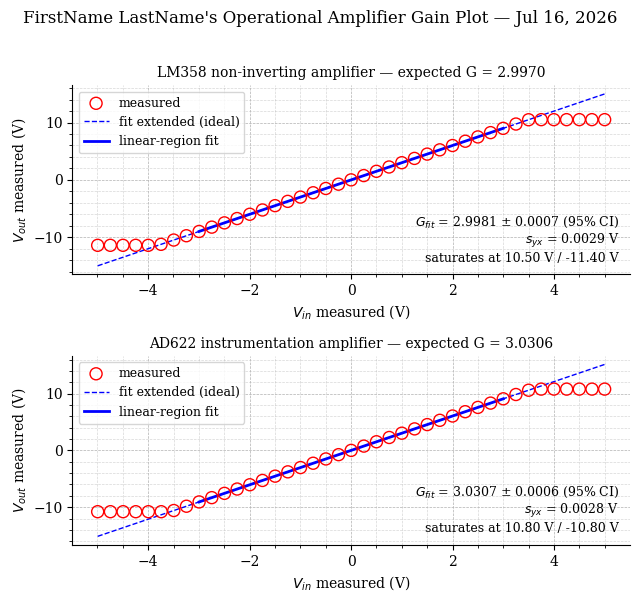

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(6.5, 6.0))
fig.patch.set_facecolor('white')

panels = [
    (axes[0], v_in_lm, v_out_lm, lin_lm, c_lm, G_lm, CI_lm, syx_lm,
     G_expected_lm, 'LM358 non-inverting amplifier'),
    (axes[1], v_in_ad, v_out_ad, lin_ad, c_ad, G_ad, CI_ad, syx_ad,
     G_expected_ad, 'AD622 instrumentation amplifier'),
]

for ax, v_in, v_out, linear, coeffs, G_fit, CI_G, s_yx, G_exp, name in panels:
    ax.scatter(v_in, v_out, s=75, facecolors='none', edgecolors='red',
               label='measured', zorder=3)
    ax.plot(v_in, np.polyval(coeffs, v_in), 'b--', linewidth=1,
            label='fit extended (ideal)')
    ax.plot(v_in[linear], np.polyval(coeffs, v_in[linear]), 'b-',
            linewidth=2, label='linear-region fit')

    ax.set_xlabel('$V_{in}$ measured (V)')
    ax.set_ylabel('$V_{out}$ measured (V)')
    ax.set_title(f'{name} — expected G = {G_exp:.4f}', fontsize=10)
    ax.grid(which='major', linestyle='--', linewidth=0.5)
    ax.grid(which='minor', linestyle='--', linewidth=0.5, alpha=0.5)
    ax.minorticks_on()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(loc='upper left', fontsize=9)

    ax.text(0.98, 0.05,
            f'$G_{{fit}}$ = {G_fit:.4f} ± {CI_G:.4f} (95% CI)\n'
            f'$s_{{yx}}$ = {s_yx:.4f} V\n'
            f'saturates at {v_out.max():.2f} V / {v_out.min():.2f} V',
            transform=ax.transAxes, ha='right', va='bottom', fontsize=9)

fig.suptitle(f"FirstName LastName's Operational Amplifier Gain Plot — {today}",
             y=0.995)
fig.tight_layout(rect=(0, 0, 1, 0.98))

fig.savefig('../Figures/FirstName_LastName_Lab05_AmpGain.png',
            dpi=600, bbox_inches='tight')
fig.savefig('../Figures/FirstName_LastName_Lab05_AmpGain.pdf',
            dpi=600, bbox_inches='tight')
plt.show()

## Part-6 — common-mode demo (hardware/GUI only; expected numbers)

Done live in WaveForms (Wavegen + Scope), no notebook data. Expected
results for the TA:

- Both inputs tied to W1 (1 V amplitude sine, common mode): output ripple
  of only a few mV — the in-amp subtracts what the inputs share.
- −IN returned to GND (differential = single-ended input): output ≈ G × 2 V
  pp ≈ 6 V pp.
- Ratio of the two output amplitudes ~ 500–5000× (CMRR of order 60–80 dB
  in-circuit; the datasheet's 100+ dB is not reachable on a breadboard —
  wire-length mismatch dominates).

## Grading / checking notes (TA)

**Gains.** Expected fitted gains: LM358 ≈ 2.99–3.00, AD622 ≈ 3.02–3.04
(depends on their actual resistors — check against THEIR recorded R values,
not the nominals). CI half-widths should be small (~0.001–0.01). A fitted
gain far from 1 + R2/R1 usually means swapped R1/R2 (gives 1.5) or a fit
performed over the *whole* sweep including saturation (drags the slope down
— look for a fit line cutting through the clipped points).

**Saturation.** LM358 clips asymmetrically (closer to V− than V+; ~+10.5 V
and less-negative than −12); AD622 roughly symmetric ±10.8 V. Students who
report "saturates at exactly ±12 V" read the rail, not their data. If a
student's output clips at ±5 V, their Ch2 scope range was left at 5 V —
the measurement saturated, not the amplifier (great teachable moment;
their raw CSV shows a perfect flat top at the range limit).

**Mask.** `np.abs(v_out) < 9.5` is the posted threshold; any sensible cut
(9–10 V) is fine. Masks defined on v_in (e.g. |v_in| < 3) also work but
should be justified.

**Offset.** The fit intercept is the output offset voltage (a few mV) —
worth praise if a student notices and names it.

**Common-mode demo.** Output with tied inputs should be mV-scale. If it is
volts-scale, REF (pin 5) is probably floating — the classic AD622 error.

**Safety/damage.** A dead LM358 usually traces to pin 4 grounded instead of
at −12 V, or supplies enabled while rewiring. Both are called out in the
manual; check wiring photos if a station reports "no output".